# Classifying audio using spectrograms
Inspired by [this notebook](https://github.com/etown/dl1/blob/master/UrbanSoundClassification.ipynb), this is an attempt at classifying animal sounds by training an image classification model on their spectrograms.

The dataset comes from Kaggle's [BirdCLEF+ 2026 competition](https://www.kaggle.com/competitions/birdclef-2026/overview).

### Download data

In [25]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('birdclef-2026')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/birdclef-2026


In [26]:
! ls /kaggle/input/competitions/birdclef-2026

recording_location.txt	test_soundscapes  train_soundscapes
sample_submission.csv	train_audio	  train_soundscapes_labels.csv
taxonomy.csv		train.csv


In [27]:
! ls /kaggle/input/competitions/birdclef-2026/train_audio

1161364  25214	  bafcur1  chacha1  greani1  masgna1  relser1  shtnig1	toctou1
116570	 326272   baffal1  chbmoc1  greant1  nacnig1  rinkin1  sibtan2	trokin
1176823  41970	  banana   chobla1  greela   ocecra1  rivwar1  smbani	trsowl
1595929  43435	  barant1  chvcon1  grekis   oliwoo1  roahaw   smbtin1	undtin1
209233	 47144	  batbel1  cibspi1  grepot1  orbtro3  rubthr1  sobcac1	varant1
22930	 476521   baymac   coffal1  gretho2  orwpar   rufcac2  sobtyr1	watjac1
22956	 516975   bbwduc   compau   greyel   osprey   rufcas2  socfly1	wesfie1
22961	 555123   bcwfin2  compot1  grfdov1  pabspi1  rufgna3  sofspi1	wfwduc1
22967	 555145   bkcdon   crbthr1  grhtan1  palhor3  rufhor2  souant1	whbant2
22973	 555146   bkhpar   crebec1  gycwor1  paltan1  rufnig1  soulap1	whbwar2
22983	 64898	  blchaw1  dwatin1  horscr1  phecuc1  ruftho1  souscr1	whiwoo1
22985	 65377	  blheag1  epaori4  houspa   picpig2  ruftof1  spbant3	whlspi1
23150	 65380	  blttit1  eulfly1  hyamac1  pirfly1  rumfly1  spispi1	whnjay1
2

In [28]:
! ls /kaggle/input/competitions/birdclef-2026/train_audio/banana

iNat1003999.ogg  iNat336997.ogg  XC127164.ogg  XC32077.ogg   XC603264.ogg
iNat1005723.ogg  iNat339877.ogg  XC127222.ogg  XC326973.ogg  XC614396.ogg
iNat1009822.ogg  iNat342892.ogg  XC128032.ogg  XC331385.ogg  XC614934.ogg
iNat1019241.ogg  iNat344526.ogg  XC131595.ogg  XC331386.ogg  XC616607.ogg
iNat1020622.ogg  iNat347546.ogg  XC146937.ogg  XC331387.ogg  XC622477.ogg
iNat1024701.ogg  iNat351449.ogg  XC146976.ogg  XC335021.ogg  XC626037.ogg
iNat1041315.ogg  iNat351818.ogg  XC147123.ogg  XC33682.ogg   XC649625.ogg
iNat1078205.ogg  iNat353343.ogg  XC149227.ogg  XC340263.ogg  XC652646.ogg
iNat1092040.ogg  iNat354802.ogg  XC151364.ogg  XC345364.ogg  XC653323.ogg
iNat1105784.ogg  iNat356423.ogg  XC154742.ogg  XC346009.ogg  XC659497.ogg
iNat1105993.ogg  iNat357060.ogg  XC155797.ogg  XC347839.ogg  XC668347.ogg
iNat1110699.ogg  iNat366408.ogg  XC155808.ogg  XC351849.ogg  XC673166.ogg
iNat1144174.ogg  iNat368645.ogg  XC169559.ogg  XC352977.ogg  XC689903.ogg
iNat1157593.ogg  iNat368646.ogg  XC169

In [29]:
# listen to a file
import IPython
sample_file_path = path + '/train_audio/banana/iNat366408.ogg'
IPython.display.Audio(sample_file_path)

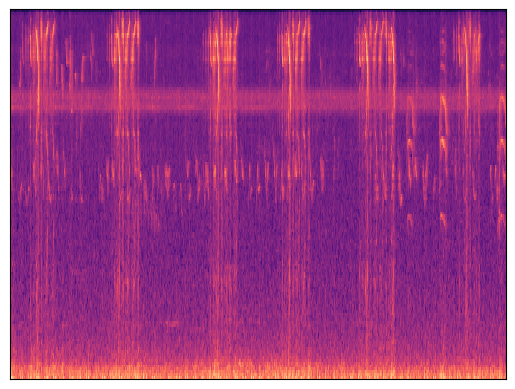

In [30]:
# view its spectrogram
import librosa
import librosa.display
import numpy as np

samples, sample_rate = librosa.load(sample_file_path)
S = librosa.feature.melspectrogram(y=samples, sr=sample_rate)
librosa.display.specshow(librosa.power_to_db(S, ref=np.max))

### Setup fastbook (from fast.ai)

In [31]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [32]:
from fastbook import *

### Process data

The test soundscapes will contain 5s clips so it makes sense to chunk these 30s clips into 5s chunks and train on that.

#### Chunking strategy
Create 2 sets of 5s chunks starting from 0s and 2.5s offsets. This approach means each 30s file will yield a slightly different number of complete chunks depending on the start offset:

- Start at 0s → chunks: 0-5, 5-10, 10-15, 15-20, 20-25, 25-30 → **6 complete chunks**
- Start at 2.5s → chunks: 2.5-7.5, 7.5-12.5, 12.5-17.5, 17.5-22.5, 22.5-27.5 → **5 complete chunks** (32.5s doesn't exist)

So across 2 offsets this process will yield roughly **11 chunks per 30s file** instead of 12.

This work was done on a separate system and the results were uploaded to the notebook's workspace to remain within Kaggle's hard disk limits.

#### Load data

In [33]:
species_folders = [
    '/kaggle/input/datasets/ucheozoemena/species-001-010',
    '/kaggle/input/datasets/ucheozoemena/species-011-090'
]

In [34]:
Path(species_folders[1]).ls()

[Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_003_rank_021-030'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_009_rank_081-090'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_015_rank_141-150'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_016_rank_151-160'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_019_rank_181-190'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_004_rank_031-040'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_005_rank_041-050'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_021_rank_201-206'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_018_rank_171-180'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_017_rank_161-170'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_013_rank_12

In [35]:
Path(species_folders[1]).ls()[0].ls()

[Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/strcuc1'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/bobfly1'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/trsowl'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/roahaw'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/bncfly'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/trokin'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/grekis'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/sobtyr1'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/whtdov'), Path('/kaggle/input/datasets/ucheozoemena/species-011-090/batch_002_rank_011-020/bbwduc')]

#### Show data

In [36]:
Path('/kaggle/input/datasets/ucheozoemena/').ls()[0].ls()

[Path('/kaggle/input/datasets/ucheozoemena/species-001-010/rubthr1'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/yeofly1'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/osprey'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/houspa'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/soulap1'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/coffal1'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/socfly1'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/compau'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/fepowl'), Path('/kaggle/input/datasets/ucheozoemena/species-001-010/banana')]

In [37]:
# Output root folder
spectrograms_dir = Path('/kaggle/input/datasets/ucheozoemena/')

imgs = get_image_files(spectrograms_dir)
len(imgs)

443645

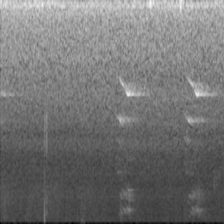

In [38]:
# view a result
img = Image.open(str(imgs[0]))
img.to_thumb(224, 224)

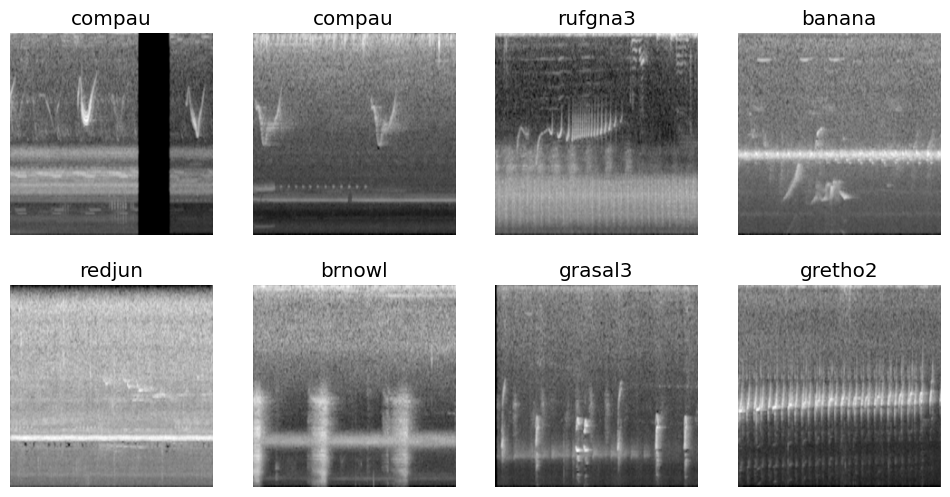

In [39]:
spectrograms = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=21),
    get_y=parent_label,
)
dls = spectrograms.dataloaders(spectrograms_dir)
dls.train.show_batch(max_n=8, nrows=2)

In [40]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time


KeyError: Caught KeyError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastai/data/transforms.py", line 263, in encodes
    return TensorCategory(self.vocab.o2i[o])
                          ~~~~~~~~~~~~~~^^^
KeyError: '23724'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 44, in fetch
    data = next(self.dataset_iter)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastai/data/load.py", line 140, in create_batches
    yield from map(self.do_batch, self.chunkify(res))
  File "/usr/local/lib/python3.12/dist-packages/fastcor

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [ ]:
learn.export()

In [ ]:
Path().ls(file_exts='.pkl')